(mmm_roas_experimentation)=
# How Much Would One Lift Test Reduce ROAS Uncertainty?

A Marketing Mix Model (MMM) gives a posterior distribution for the return on ad spend (ROAS) of every channel. That posterior is often wide, because sales data alone cannot separate the channels well. A lift test is the standard remedy, but it costs money and time, so a natural question comes before the test: **how much would one lift test narrow the ROAS posterior?**

This notebook answers that question with the fitted model itself. The idea is a *pre-posterior analysis*: we simulate the test results the model considers possible, update the posterior for each result, and measure how much the ROAS uncertainty shrinks on average. The update does not refit the model. It reuses the posterior draws we already have, with importance weights.

We use the same data and the same model as the {ref}`mmm_case_study`, so the modelling steps are kept short. To learn how to feed a real lift test result into a model, see {ref}`mmm_lift_test`.

The method has four steps:

1. **Express the test as a model quantity.** For every posterior draw, compute the lift the model implies for the planned spend increase.
2. **Update without refitting.** Treat a test result as one more observation and re-weight the existing posterior draws by how well they agree with it.
3. **Resample.** Draw from the weighted posterior to read off the ROAS uncertainty after the test.
4. **Average over the results we do not know yet.** Simulate many possible test results from the model and repeat steps 2 and 3 for each one.

```{admonition} What you will learn
:class: tip

1. How to express a planned lift test as a quantity of the fitted MMM.
2. How to update a posterior with importance weights instead of a refit, and when that shortcut is safe.
3. How to simulate unknown test results and summarise the expected gain in ROAS precision.
```

## Prepare Notebook

In [1]:
import inspect
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
import pytensor.tensor as pt
import pytensor.xtensor as ptx
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from scipy.stats import Normal

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

## Fit the Baseline MMM

We load the weekly data of the case study, keep seven media channels and the holiday indicators, and fit the model on the period up to February 2018. The gray sales in the plots below are the held-out period. See the {ref}`mmm_case_study` for the details of the data and the model choices.

In [2]:
# Demo data used in the PyMC-Marketing MMM case study.
raw_df = pd.read_csv("https://raw.githubusercontent.com/sibylhe/mmm_stan/main/data.csv")

# Controls: keep only holiday indicators.
control_columns = [col for col in raw_df.columns if "hldy_" in col]

# Media: use a small set of channels with readable names.
channel_columns_raw = sorted(
    [
        col
        for col in raw_df.columns
        if "mdsp_" in col
        and col != "mdsp_viddig"
        and col != "mdsp_auddig"
        and col != "mdsp_sem"
    ]
)

channel_mapping = {
    "mdsp_dm": "Direct Mail",
    "mdsp_inst": "Insert",
    "mdsp_nsp": "Newspaper",
    "mdsp_audtr": "Radio",
    "mdsp_vidtr": "TV",
    "mdsp_so": "Social Media",
    "mdsp_on": "Online Display",
}

channel_columns = sorted(list(channel_mapping.values()))
n_channels = len(channel_columns)
sales_col = "sales"

data_df = raw_df[["wk_strt_dt", sales_col, *channel_columns_raw, *control_columns]]
data_df = data_df.rename(columns=channel_mapping)

data_df["wk_strt_dt"] = pd.to_datetime(data_df["wk_strt_dt"])
date_column = "wk_strt_dt"
target_column = "sales"

# Fit on the historical period, then use the held-out period for display.
train_test_split_date = pd.to_datetime("2018-02-01")

train_mask = data_df.wk_strt_dt <= train_test_split_date
test_mask = data_df.wk_strt_dt > train_test_split_date

train_df = data_df[train_mask]
test_df = data_df[test_mask]

X_train = train_df.drop(columns=sales_col)
y_train = train_df[sales_col]

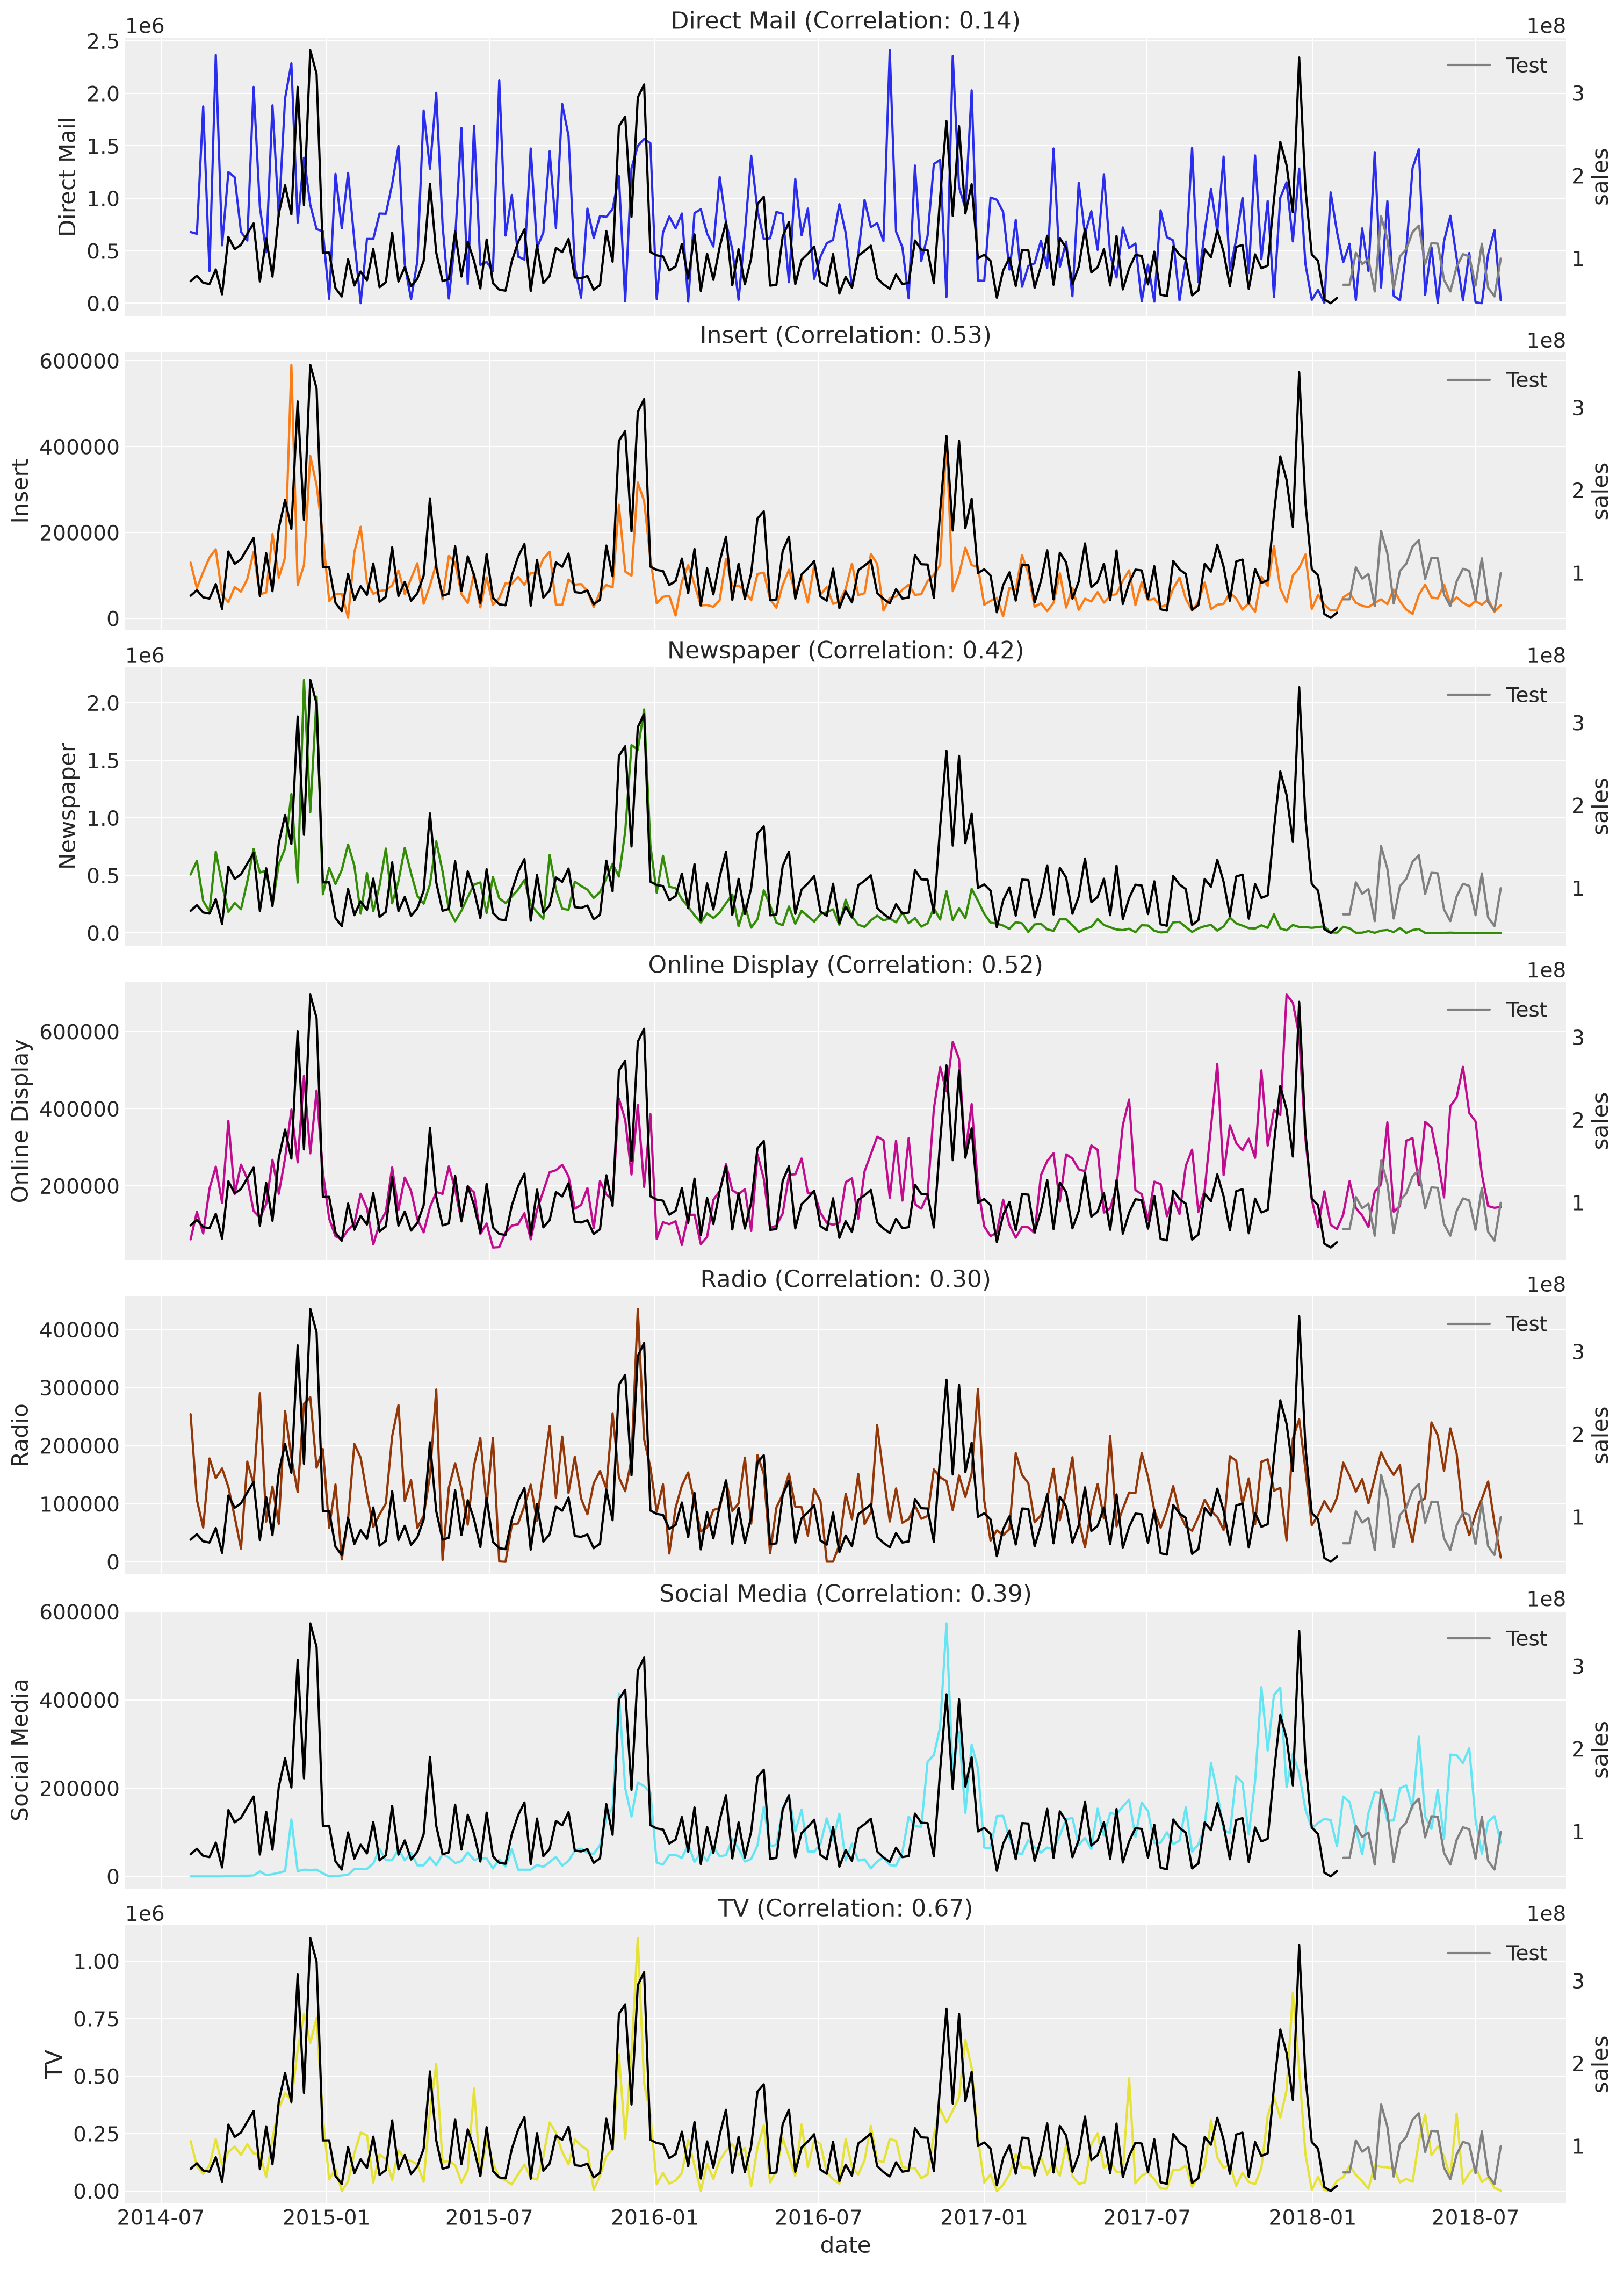

In [3]:
fig, axes = plt.subplots(
    nrows=n_channels,
    ncols=1,
    figsize=(15, 3 * n_channels),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for i, channel in enumerate(channel_columns):
    ax = axes[i]
    ax_twin = ax.twinx()
    sns.lineplot(data=data_df, x=date_column, y=channel, color=f"C{i}", ax=ax)
    sns.lineplot(
        data=train_df,
        x=date_column,
        y=sales_col,
        color="black",
        ax=ax_twin,
    )
    sns.lineplot(
        data=test_df,
        x=date_column,
        y=sales_col,
        color="gray",
        label="Test",
        ax=ax_twin,
    )
    correlation = train_df[[channel, sales_col]].corr().iloc[0, 1]
    ax_twin.grid(None)
    ax.set(title=f"{channel} (Correlation: {correlation:.2f})")

ax.set_xlabel("date");

The model has geometric adstock, logistic saturation, holiday controls, and yearly seasonality. We fit it with the same sampler settings as the case study: six chains of 800 draws after 1500 tuning steps with `target_accept=0.9`. The budget is generous on purpose: the comparison at the end works with the spread of the posterior, so we do not want MCMC noise to dominate it.

In [4]:
spend_shares = (
    X_train.melt(value_vars=channel_columns, var_name="channel", value_name="spend")
    .groupby("channel", as_index=False)
    .agg({"spend": "sum"})
    .sort_values(by="channel")
    .assign(spend_share=lambda x: x["spend"] / x["spend"].sum())["spend_share"]
    .to_numpy()
)

prior_sigma = spend_shares

model_config = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.05),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
}

sampler_config = {"progressbar": True}

mmm = MMM(
    model_config=model_config,
    sampler_config=sampler_config,
    target_column=target_column,
    date_column=date_column,
    adstock=GeometricAdstock(l_max=6),
    saturation=LogisticSaturation(),
    channel_columns=channel_columns,
    control_columns=control_columns,
    yearly_seasonality=5,
)

mmm.build_model(X_train, y_train)

# Add the contribution variables to the model
# to track them in the model and trace.
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)


mmm.fit(
    X=X_train,
    y=y_train,
    target_accept=0.9,
    chains=6,
    cores=6,
    draws=800,
    tune=1_500,
    nuts_sampler="nutpie",
    random_seed=rng,
)

mmm.plot_suite = "new"

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pymc_extras/prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)
NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


## ROAS Before the Test

For every posterior draw, the ROAS of a channel is its incremental contribution over the training period divided by its total spend. The incremental contribution is the difference between the fitted sales and the counterfactual sales with the channel's spend set to zero, with adstock carry-over included. We compute it with {meth}`~pymc_marketing.mmm.incrementality.Incrementality.contribution_over_spend`, as in the {ref}`mmm_case_study`. This is the definition the library recommends, and it is not the same as the sum of the fitted channel contribution divided by spend. The ROAS is the quantity whose uncertainty we want to reduce.

In [5]:
# Incremental ROAS per posterior draw over the whole training period.
mmm.idata["posterior"]["ROAS"] = mmm.incrementality.contribution_over_spend(
    frequency="all_time"
)

The current ROAS posteriors are wide for all channels. For Online Display, the channel we will test, the posterior mean is about 52 and the standard deviation is about 37. This is the "before" picture.

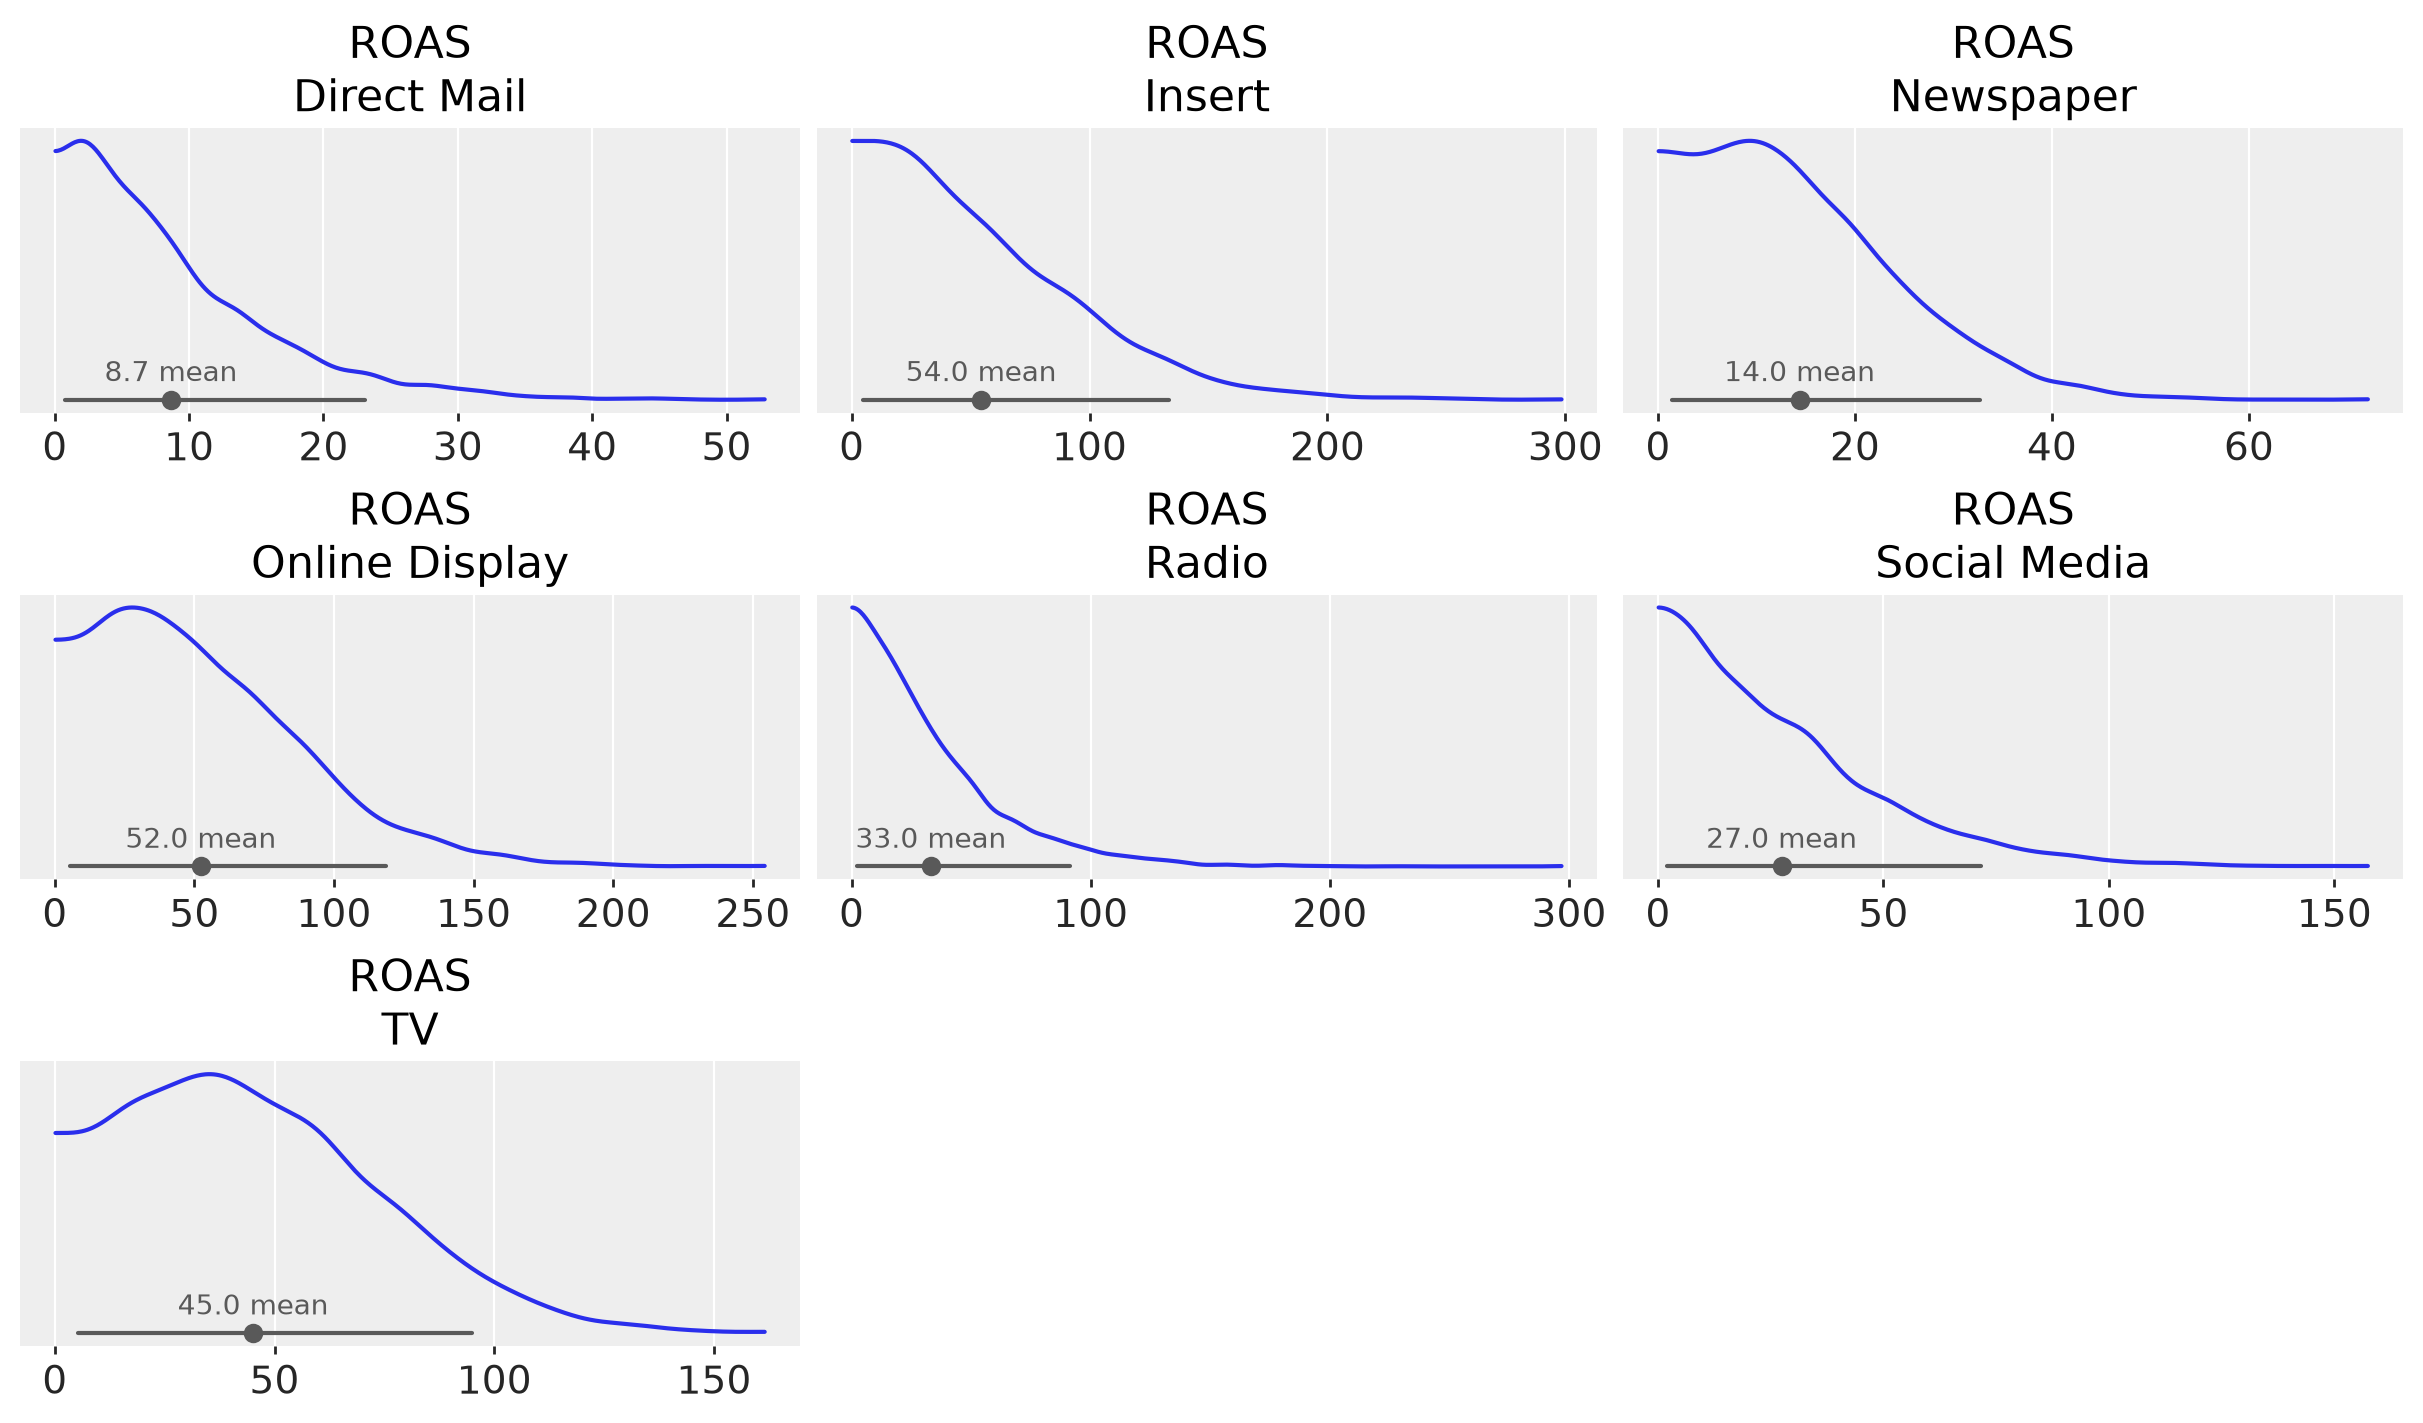

In [6]:
az.plot_dist(
    mmm.idata,
    var_names=["ROAS"],
    col_wrap=3,
    figure_kwargs={"figsize": (12, 7)},
);

## Simulating One Lift Test Without Refitting

**Step 1: the test as a model quantity.** A lift test raises the weekly spend of one channel from $x_\text{start}$ to $x_\text{end}$ and measures the incremental sales. The saturation curve $f$ of the fitted model gives the lift it implies for posterior draw $s$:

$$
\Delta_s = f(x_\text{end}; \theta_s) - f(x_\text{start}; \theta_s).
$$

This is the immediate response of the saturation curve, without adstock carry-over. It is the same convention that {meth}`~pymc_marketing.mmm.mmm.MMM.add_lift_test_measurements` uses when it calibrates a model on a real lift test.

**Step 2: update without refitting.** Suppose the test reports a lift $\hat{\Delta}$ with measurement noise $\sigma_\text{test}$. In Bayes' rule this is one more likelihood term:

$$
p(\theta \mid y, \hat{\Delta}) \propto p(\theta \mid y)\, \text{Normal}(\hat{\Delta} \mid \Delta(\theta), \sigma_\text{test}).
$$

We already have draws from $p(\theta \mid y)$. So the posterior after the test is the same set of draws with weights $w_s \propto \text{Normal}(\hat{\Delta} \mid \Delta_s, \sigma_\text{test})$. This is importance sampling. We use Pareto smoothed importance sampling (PSIS) to stabilise the weights; it also returns a Pareto $\hat{k}$ diagnostic that tells us when the weights are unreliable. The weights are normalised within each chain.

**Step 3: resample.** We resample the posterior draws with the weights. The resampled draws are a posterior for every model quantity after the test, including ROAS, and we record its standard deviation.

**Step 4: average over unknown results.** Before the test runs, $\hat{\Delta}$ is unknown. The model tells us which results are plausible: pick one posterior draw $s^*$ at random as the temporary truth and add test noise,

$$
\hat{\Delta} \sim \text{Normal}(\Delta_{s^*}, \sigma_\text{test}).
$$

We repeat this many times. Each simulated result gives one post-test ROAS standard deviation. The reduction relative to the current standard deviation, averaged over all simulated results, is the expected gain in ROAS precision from the test.

```{admonition} When does the shortcut break?
:class: note

Importance sampling reuses the draws we have. If the test is much more precise than the spread of the implied lift $\Delta_s$ across the posterior, only a few draws are compatible with any result and they carry all the weight. Compare `test_sigma / mmm.scalers._target` with `mmm.idata.posterior.lift.std()`, and check the `k_hat` value stored for each simulated experiment (values above 0.7 signal unreliable weights). For a very precise test, refit the model with the simulated result through `add_lift_test_measurements` instead.
```

### Helper functions

`compile_saturation_fn` compiles the saturation curve of the model once, so that we can evaluate it for all posterior draws at any spend level (step 1).

In [7]:
def compile_saturation_fn(mmm):
    """Compile and cache the channel saturation curve for fast lift simulations."""
    if hasattr(mmm.saturation, "_compiled_fn"):
        return mmm.saturation._compiled_fn

    sig = inspect.signature(mmm.saturation.function)
    param_names = [
        p.name
        for p in sig.parameters.values()
        if p.name not in ("x", "dim") and p.default == inspect.Parameter.empty
    ]
    x = ptx.as_xtensor(pt.vector("x"), dims=("x",))
    inputs = [x]
    param_tensors = []
    for name in param_names:
        var_name = mmm.saturation.variable_mapping[name]
        arr = mmm.idata["posterior"][var_name]
        ndim = arr.ndim
        dims = tuple(arr.dims)
        if ndim == 0:
            tensor = pt.scalar(name)
        elif ndim == 1:
            tensor = pt.vector(name)
        elif ndim == 2:
            tensor = pt.matrix(name)
        elif ndim == 3:
            tensor = pt.tensor3(name)
        else:
            tensor = pt.TensorType("float64", [False] * ndim)(name)
        xtensor_var = ptx.as_xtensor(tensor, dims=dims)
        param_tensors.append(xtensor_var)
        inputs.append(tensor)
    out = mmm.saturation.function(x, *param_tensors)
    fn = pytensor.function(inputs, out)
    mmm.saturation._compiled_fn = fn
    return fn

`sample_lift_experiments` computes the implied lift of every posterior draw for the planned spend increase, then simulates the requested number of test results and the PSIS weights for each of them (steps 1, 2, and 4). The implied lift is stored in the posterior as `lift`, so you can inspect it.

In [8]:
def sample_lift_experiments(
    n_experiments, x_start, x_end, lift_test_sigma, mmm, channel_name
):
    """Simulate possible one-test outcomes and their posterior weights.

    Each experiment chooses one posterior draw as the temporary ``truth``. The
    observed lift is that draw's lift plus test noise. PSIS weights then
    approximate the posterior after seeing that one noisy result.
    """
    import inspect

    x_max = x_end / mmm.scalers._channel.sel(channel=channel_name)
    x_min = x_start / mmm.scalers._channel.sel(channel=channel_name)
    sat_fn = compile_saturation_fn(mmm)

    sig = inspect.signature(mmm.saturation.function)
    param_names = [
        p.name
        for p in sig.parameters.values()
        if p.name not in ("x", "dim") and p.default == inspect.Parameter.empty
    ]
    channel_idx = list(mmm.idata["posterior"].coords["channel"].values).index(
        channel_name
    )

    # Implied lift of every posterior draw (shared by all experiments).
    param_vals_full = [
        mmm.idata["posterior"][mmm.saturation.variable_mapping[name]].values
        for name in param_names
    ]
    lift_max = sat_fn(np.array([x_max]), *param_vals_full).squeeze(axis=-1)
    lift_min = sat_fn(np.array([x_min]), *param_vals_full).squeeze(axis=-1)
    lift_values = (lift_max - lift_min)[:, :, channel_idx]

    mmm.idata["posterior"]["lift"] = xr.DataArray(
        data=lift_values,
        dims=["chain", "draw"],
        coords={
            "chain": mmm.idata["posterior"].coords["chain"],
            "draw": mmm.idata["posterior"].coords["draw"],
        },
    )

    lift = mmm.idata["posterior"]["lift"]
    n_chains, n_draws = lift.shape
    sigma = lift_test_sigma / mmm.scalers._target.values

    experiments = []
    for _ in range(n_experiments):
        chain_i = int(rng.integers(0, n_chains))
        draw_i = int(rng.integers(0, n_draws))
        true_lift = float(lift.values[chain_i, draw_i])
        lift_obs = float(rng.normal(loc=true_lift, scale=sigma))

        lw, k_hat = az.base.array_stats.psislw(
            -Normal(mu=lift_obs, sigma=sigma).logpdf(lift.values)
        )
        experiments.append(
            {
                "chain": chain_i,
                "draw": draw_i,
                "lift_obs": lift_obs,
                "weights": np.exp(lw),
                "k_hat": float(k_hat[0]),
            }
        )
    return experiments

`resample_posterior` draws a weighted sample of every posterior variable (step 3). It copies all variables, which is why the loop over 1000 experiments below takes a few minutes.

In [9]:
def resample_posterior(idata, weights, num_samples=500):
    """Draw a weighted posterior sample after a simulated lift test."""
    posterior = idata["posterior"]
    n_chains = posterior.sizes["chain"]
    n_draws = posterior.sizes["draw"]
    flat_weights = np.asarray(weights).flatten()
    flat_weights = flat_weights / flat_weights.sum()

    idx = rng.choice(
        n_chains * n_draws,
        size=num_samples,
        p=flat_weights,
        replace=True,
    )
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws

    resampled_vars = {}
    for var in posterior.data_vars:
        da = posterior[var]
        extra_dims = [d for d in da.dims if d not in ("chain", "draw")]
        indexed = da.values[chain_idx, draw_idx]
        # Reshape to (1, num_samples, ...) for consistent chain/draw structure
        reshaped = indexed.reshape((1, num_samples, *indexed.shape[1:]))
        coords = {"chain": [0], "draw": range(num_samples)}
        for d in extra_dims:
            coords[d] = da.coords[d].values
        resampled_vars[var] = xr.DataArray(
            reshaped,
            dims=["chain", "draw", *extra_dims],
            coords=coords,
        )
    resampled = xr.Dataset(resampled_vars)
    out = xr.DataTree.from_dict({"posterior": resampled})
    out.attrs = getattr(idata, "attrs", {}).copy()
    return out

## Choose the Experiment

Four numbers define the test:

- `channel_selection`: the channel to test.
- `start_spend` and `test_budget`: the weekly spend before the increase and the size of the increase, in the units of the spend columns. They are two points on the saturation curve, not the cost of running the experiment. Here the test moves Online Display from 50,000 to 100,000 per week, at the low end of the spend levels seen in the training data.
- `test_sigma`: the standard deviation of the measured lift, in sales units. It is about 1 percent of a typical training week's sales. A lower value means a more precise, and usually more expensive, experiment. The function converts it to the scaled target of the model.

In [10]:
channel_selection = "Online Display"
test_budget = 50_000
start_spend = 50_000
test_sigma = 1_000_000

## Run the Simulations

We simulate 1000 possible test results and their posterior weights.

In [11]:
# Draw many possible one-test outcomes for the selected channel.
experiments = sample_lift_experiments(
    1_000,
    start_spend,
    start_spend + test_budget,
    test_sigma,
    mmm,
    channel_selection,
)

For each simulated result, we resample the posterior and record the ROAS standard deviation of every channel.

In [12]:
%%time

# For each simulated lift test, estimate the posterior ROAS uncertainty.
stds = [
    resample_posterior(mmm.idata, e["weights"])["posterior"]["ROAS"].std(
        ["chain", "draw"]
    )
    for e in experiments
]

CPU times: user 11.6 s, sys: 3.57 s, total: 15.1 s
Wall time: 16.4 s


## Results: Expected Reduction in ROAS Uncertainty

The plot shows, for every channel, the distribution over the simulated test results of the reduction in the ROAS standard deviation (current minus post-test).

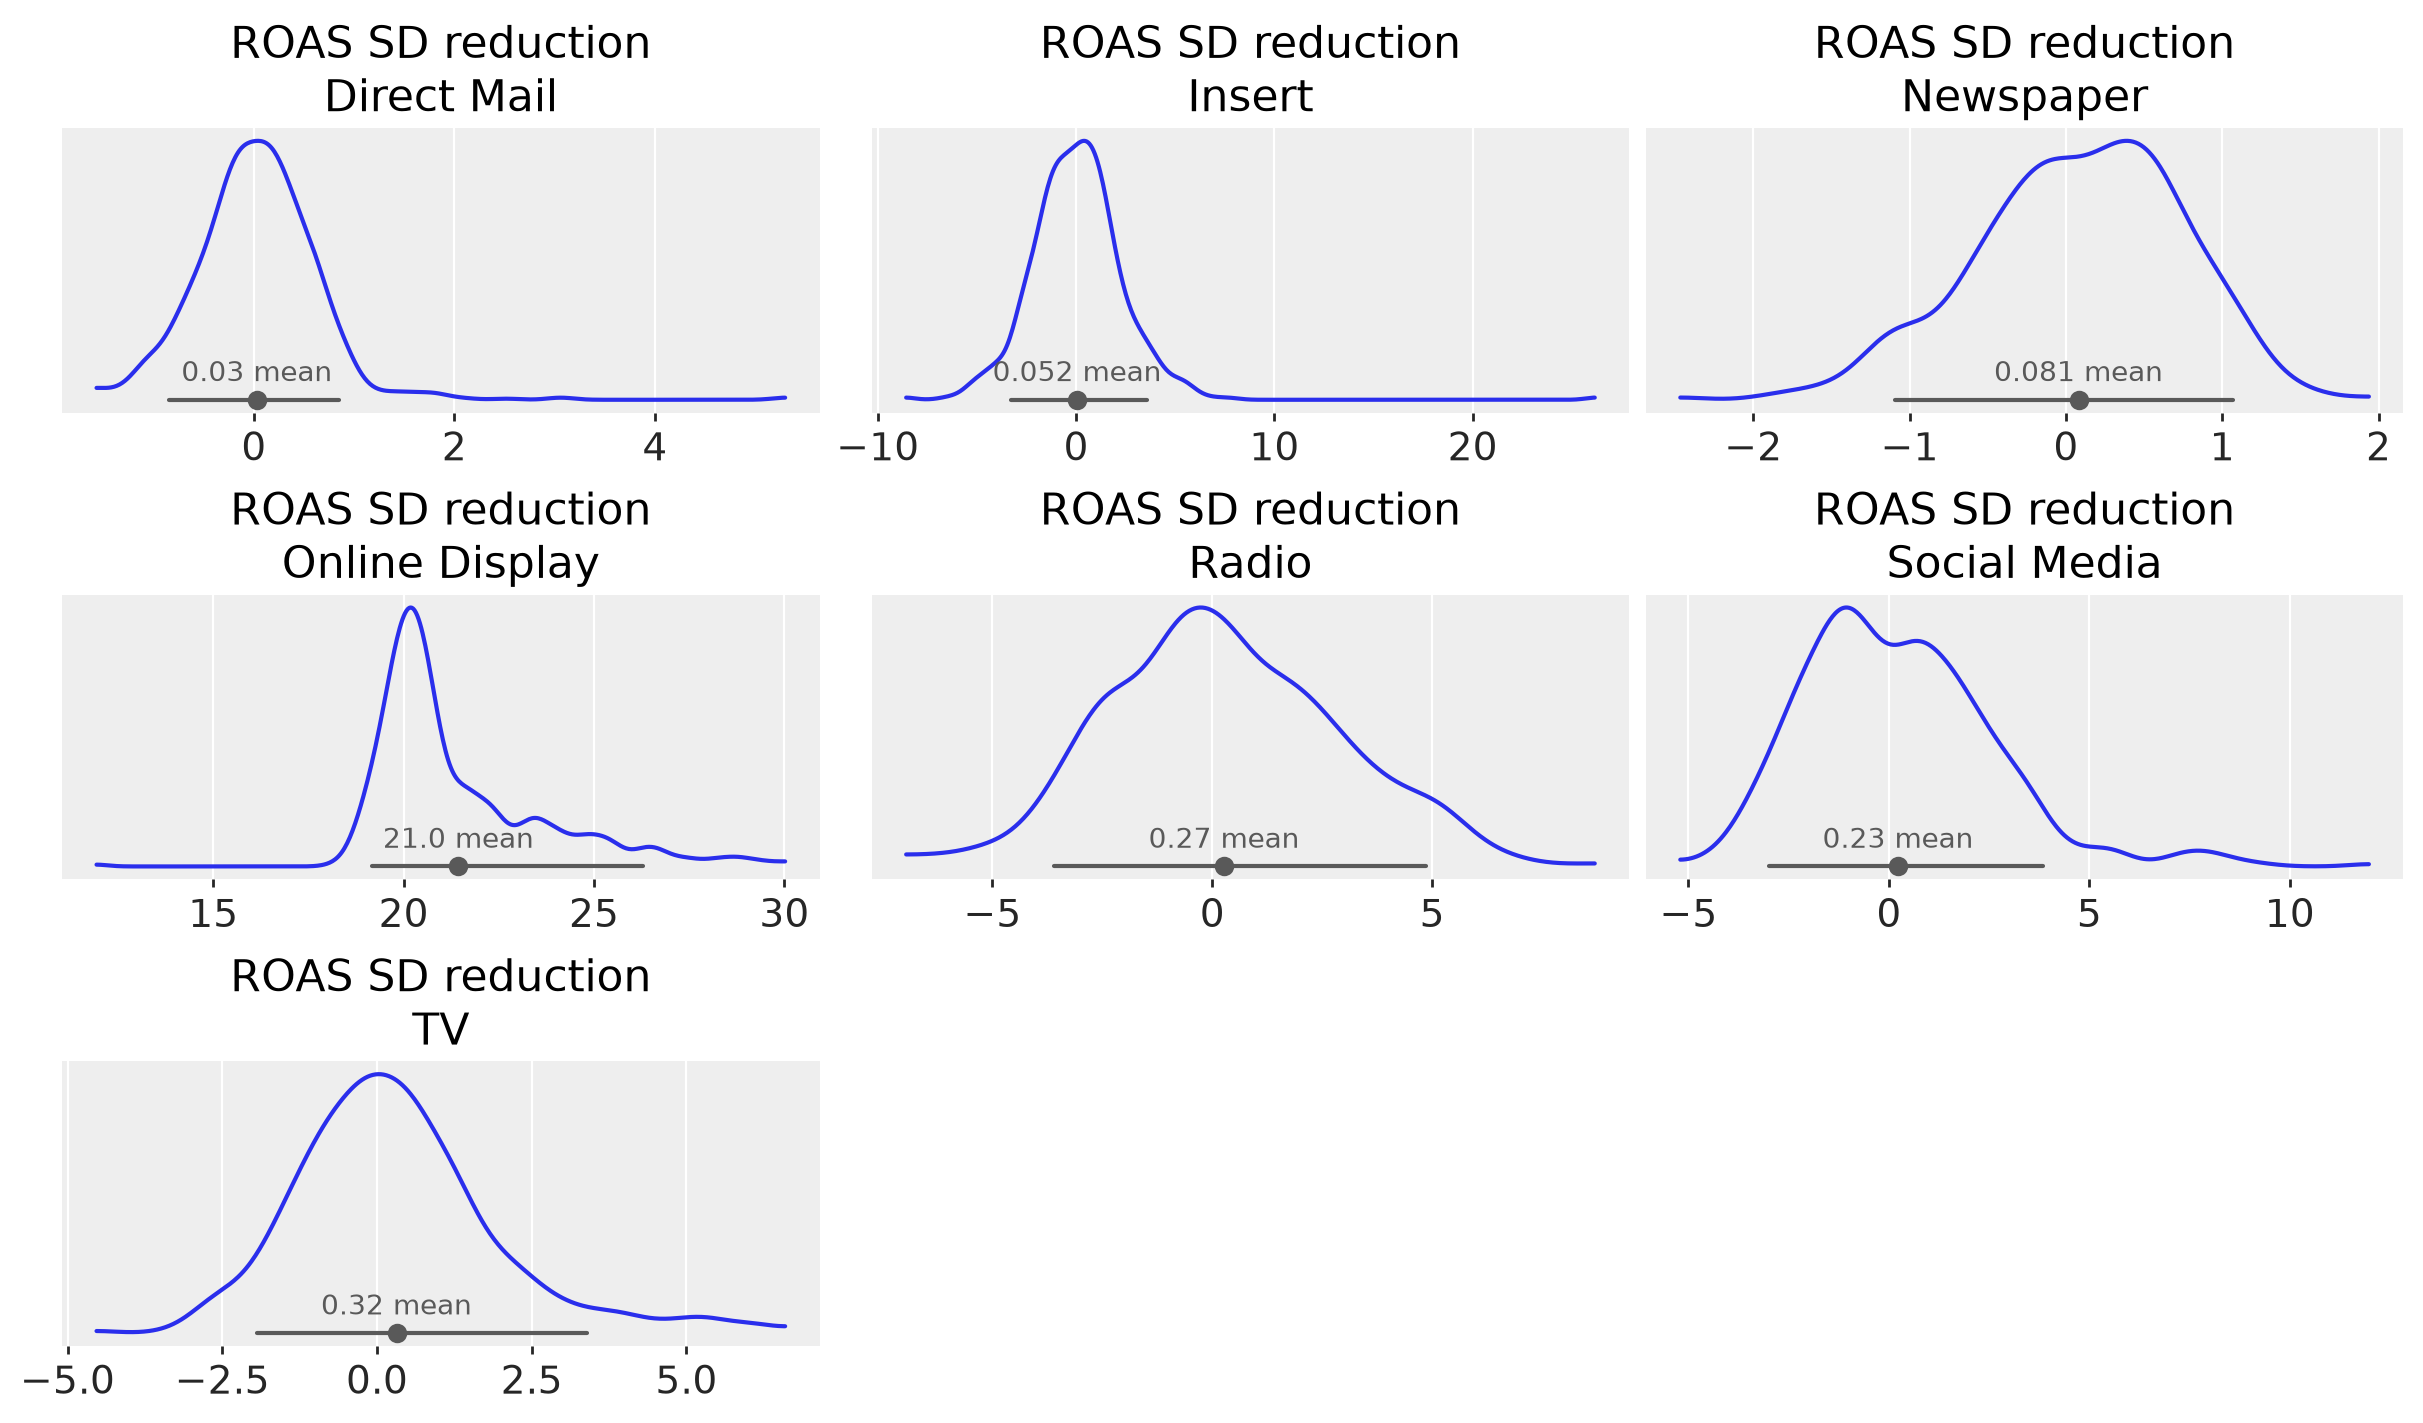

In [13]:
roas_sd_reduction = mmm.idata["posterior"]["ROAS"].std(["chain", "draw"]) - xr.concat(
    stds, dim="test"
)

az.plot_dist(
    xr.Dataset({"ROAS SD reduction": roas_sd_reduction}),
    sample_dims="test",
    col_wrap=3,
    figure_kwargs={"figsize": (12, 7)},
);

The forest plot gives a concrete picture of the precision gain. It compares the ROAS posterior before the test with the posterior after one typical simulated result: the experiment whose observed lift is the median of all simulated results. Points are posterior means, thick lines the 50% and thin lines the 94% highest density intervals.

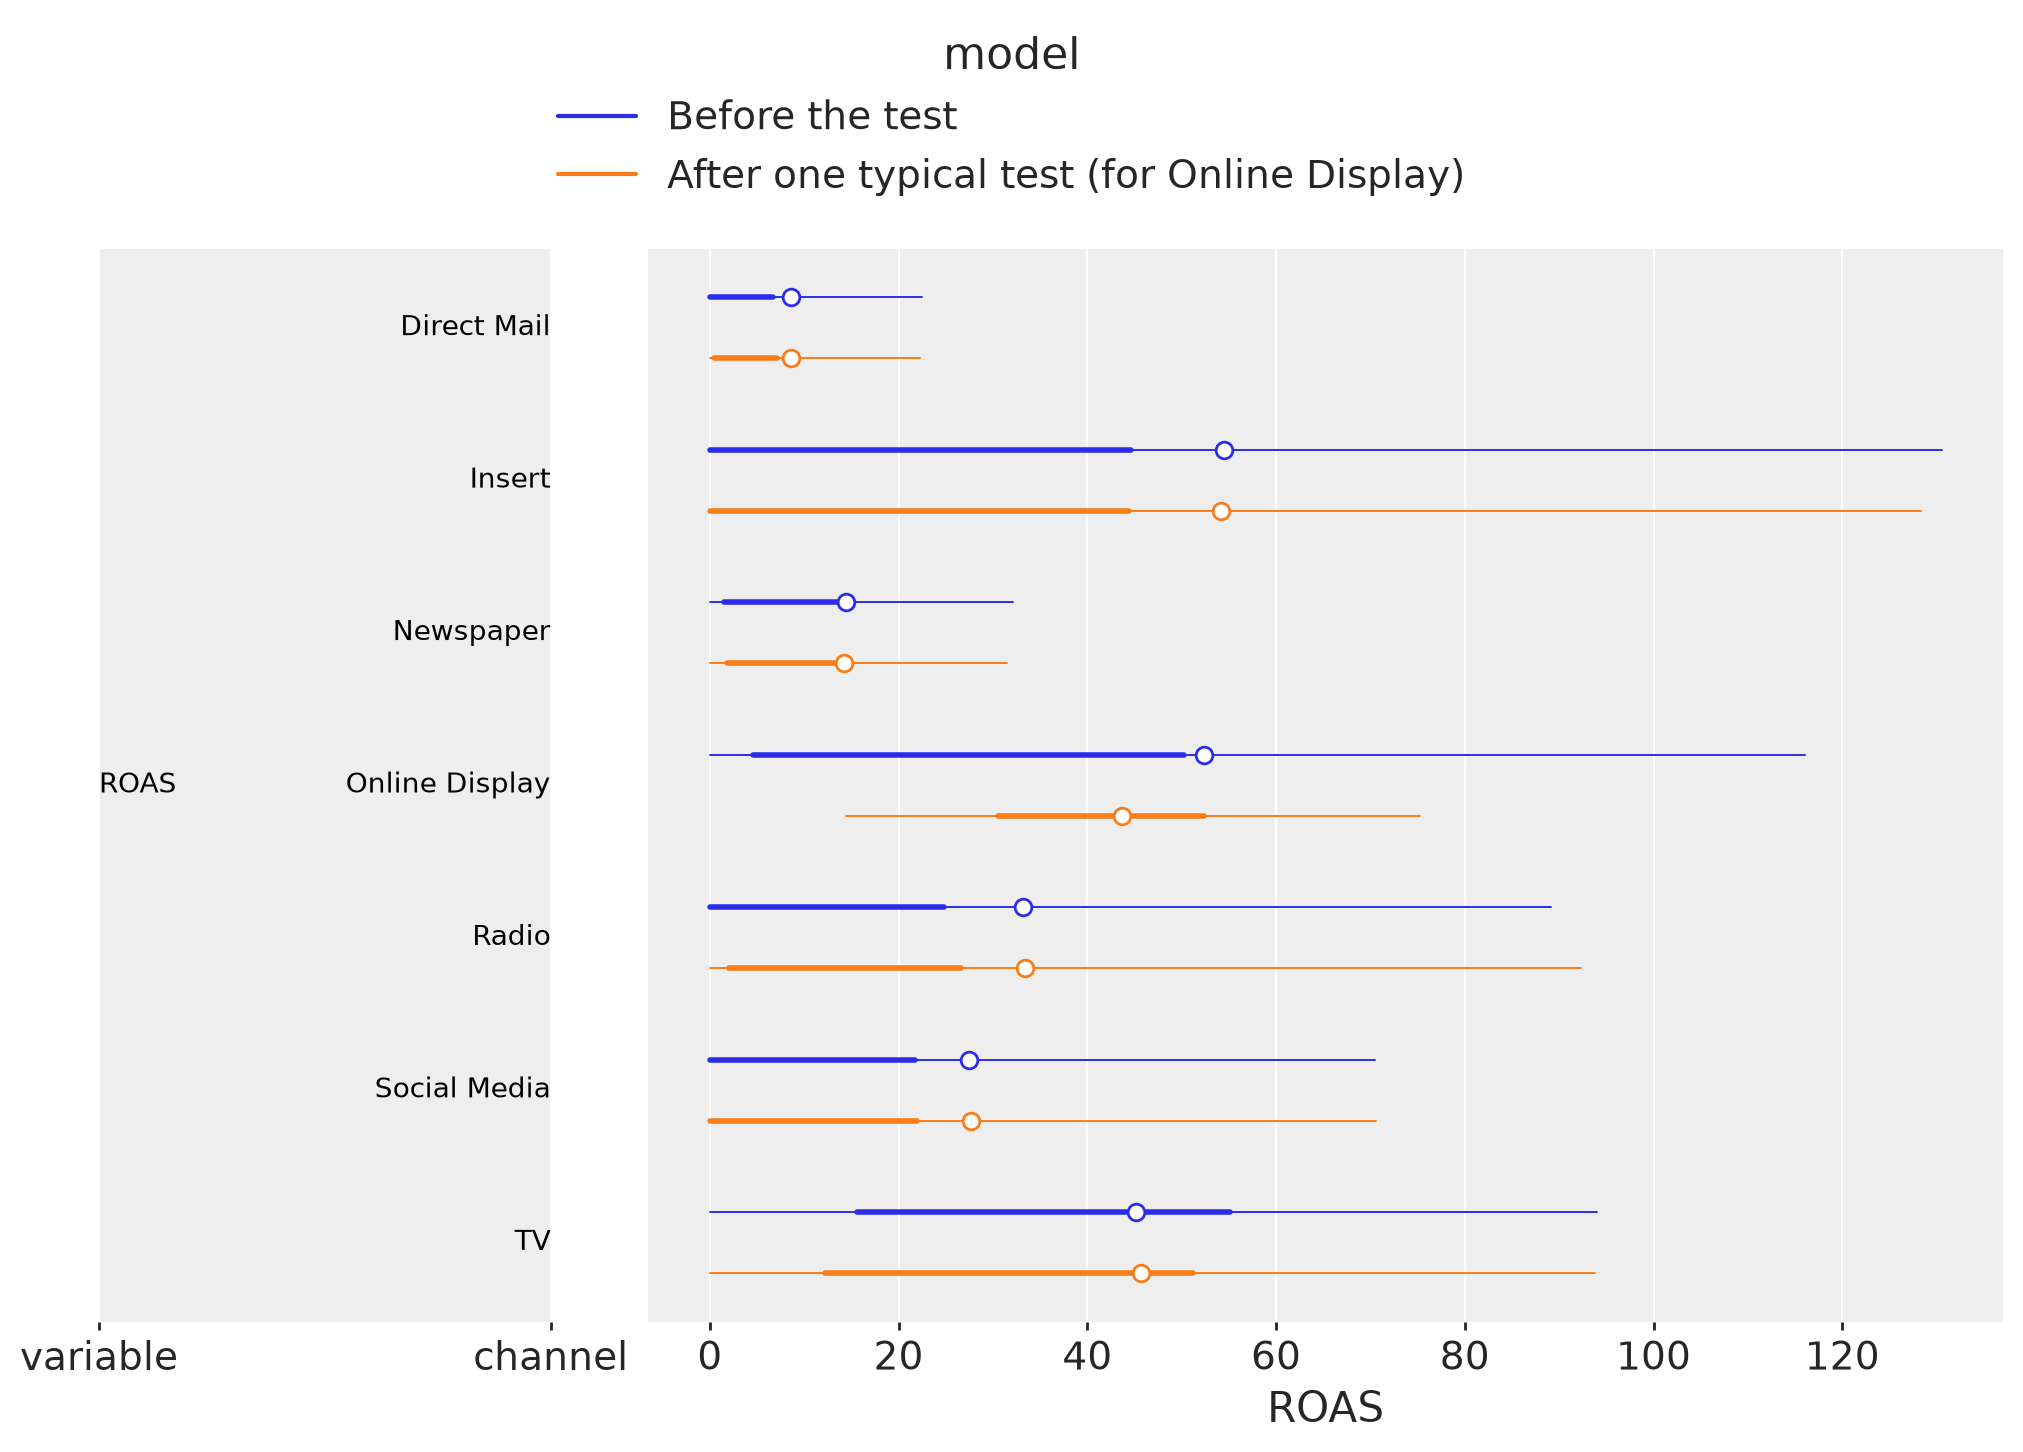

In [43]:
# One typical simulated result: the observed lift closest to the median of all results.
lift_obs = np.array([e["lift_obs"] for e in experiments])
typical_experiment = experiments[int(np.argmin(np.abs(lift_obs - np.median(lift_obs))))]

n_samples = mmm.idata["posterior"].sizes["chain"] * mmm.idata["posterior"].sizes["draw"]
posterior_after = resample_posterior(
    mmm.idata, typical_experiment["weights"], num_samples=n_samples
)


def flatten_roas(idata):
    """Stack chains and draws into one sample dimension so both posteriors align."""
    roas = idata["posterior"].to_dataset()[["ROAS"]]
    roas = roas.stack(sample=("chain", "draw")).drop_vars(["sample", "chain", "draw"])
    return xr.DataTree.from_dict({"posterior": roas})


pc = az.plot_forest(
    {
        "Before the test": flatten_roas(mmm.idata),
        f"After one typical test (for {channel_selection})": flatten_roas(
            posterior_after
        ),
    },
    var_names=["ROAS"],
    sample_dims=["sample"],
    ci_kind="hdi",
    ci_probs=(0.5, 0.94),
    figure_kwargs={"figsize": (10, 6)},
)
pc.viz["plot"][1].item().set(xlabel="ROAS")
pc.add_legend(
    "model", title_fontsize=16, loc="upper center", bbox_to_anchor=(0.5, 1.2)
);

For Online Display, the tested channel, the interval after the test is about half as wide as before, and the mean moves toward the simulated result. The intervals of the other channels are the same before and after the test.

The table summarises both plots per channel: the ROAS posterior mean and standard deviation before the test, the mean post-test standard deviation, and the mean reduction with the central 94% of the simulated results.

In [15]:
quantiles = roas_sd_reduction.quantile([0.03, 0.97], dim="test")

summary_df = xr.Dataset(
    {
        "roas_mean_before": mmm.idata["posterior"]["ROAS"].mean(["chain", "draw"]),
        "sd_before": mmm.idata["posterior"]["ROAS"].std(["chain", "draw"]),
        "sd_after_mean": xr.concat(stds, dim="test").mean("test"),
        "reduction_mean": roas_sd_reduction.mean("test"),
        "reduction_q03": quantiles.sel(quantile=0.03).drop_vars("quantile"),
        "reduction_q97": quantiles.sel(quantile=0.97).drop_vars("quantile"),
    }
).to_dataframe()

summary_df.assign(
    reduction_pct=100 * summary_df["reduction_mean"] / summary_df["sd_before"]
).round(2)

,roas_mean_before,sd_before,sd_after_mean,reduction_mean,reduction_q03,reduction_q97,reduction_pct
channel,,,,,,,
Direct Mail,8.66,7.41,7.38,0.03,-1.06,0.99,0.41
Insert,54.47,42.68,42.63,0.05,-4.16,4.35,0.12
Newspaper,14.39,10.07,9.99,0.08,-1.22,1.16,0.81
Online Display,52.34,36.63,15.19,21.44,18.98,27.36,58.53
Radio,33.19,30.10,29.83,0.27,-4.28,5.30,0.89
Social Media,27.44,23.14,22.91,0.23,-3.40,5.48,0.98
TV,45.14,28.49,28.17,0.32,-2.39,4.40,1.11


For Online Display, the tested channel, the ROAS standard deviation falls from about 37 to about 15 on average, a reduction of about 59 percent. The central 94% of the simulated results give a reduction between 19 and 27. Each post-test standard deviation is estimated from 500 resampled draws, so the fine shape of the distribution is partly resampling noise.

For the other channels the reduction is centred near zero, and the spread around zero is mostly resampling noise. A centre shifted away from zero would be the sign that the test also informs a channel through parameters that the channels share. In this model that transfer is negligible: one test on Online Display sharpens the ROAS of Online Display and almost nothing else.

## Conclusion

A fitted MMM can tell us, before we run a lift test, how much that test would sharpen a ROAS estimate. The recipe is a pre-posterior analysis: simulate the test results the model considers possible, update the posterior for each result with importance weights instead of a refit, and average the resulting reduction in ROAS uncertainty. Here, one test on Online Display is expected to cut the ROAS standard deviation by about 59 percent and to leave the other channels unchanged.

To compare candidate tests, change the channel, the spend levels, or the test precision and run the cells from "Choose the Experiment" again. Compare the relative reductions and weigh them against what each experiment would cost. Once a test has run, feed the measured lift into the model with {meth}`~pymc_marketing.mmm.mmm.MMM.add_lift_test_measurements`, as shown in {ref}`mmm_lift_test`.

Keep these limits in mind:

- The forecast is model-based. The simulated results come from the current posterior, so a misspecified model gives a misleading forecast of what the test will teach.
- The implied lift is the immediate saturation response. Adstock carry-over is not part of it.
- Importance sampling is reliable only when the test does not move the posterior far. For a very precise test, refit instead.
- The standard deviation is one criterion. Expected information gain, or the expected value of a budget decision, are alternatives that the same simulation supports.

## References

- Raiffa, H. and Schlaifer, R. (1961). *Applied Statistical Decision Theory*. Harvard University Press.
- Chaloner, K. and Verdinelli, I. (1995). Bayesian experimental design: a review. *Statistical Science*, 10(3), 273 to 304.
- Vehtari, A., Simpson, D., Gelman, A., Yao, Y., and Gabry, J. (2024). Pareto smoothed importance sampling. *Journal of Machine Learning Research*, 25(72), 1 to 58.

In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Mon, 07 Sep 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
pytensor      : 3.2.4
scipy         : 1.18.0
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

